# Simulated macro-financial variables

This exploratory notebook generates latent regimes, simulated macro-financial variables, and simulated charge-off rates. It does **not** train PtO, black-box, or DFL models.

## 1. Imports and setup

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
rng = np.random.default_rng(SEED)
np.random.seed(SEED)

if "seaborn-v0_8-whitegrid" in plt.style.available:
    plt.style.use("seaborn-v0_8-whitegrid")
elif "seaborn-whitegrid" in plt.style.available:
    plt.style.use("seaborn-whitegrid")
else:
    plt.style.use("default")
pd.set_option("display.max_columns", 100)


def find_repo_root(start=None):
    """Find the repository root from either repo root or models/simulation."""
    start = Path.cwd() if start is None else Path(start).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "data" / "processed").exists() and (candidate / "models").exists():
            return candidate
    raise RuntimeError("Could not find repo root. Set REPO_ROOT manually in this cell.")


REPO_ROOT = find_repo_root()
MODELS_SRC = REPO_ROOT / "models" / "src"
if str(MODELS_SRC) not in sys.path:
    sys.path.insert(0, str(MODELS_SRC))

try:
    from capital_allocation_utils import CapitalConfig, annualised_pd_from_chargeoff, optimise_oracle_alpha
    HAS_OPTIMISATION_UTILS = True
except ImportError as exc:
    print(f"Could not import optimisation utilities: {exc}")
    HAS_OPTIMISATION_UTILS = False

print(f"Repo root: {REPO_ROOT}")
print(f"Optimisation utilities available: {HAS_OPTIMISATION_UTILS}")

Repo root: /Users/hannahokeeffe/Documents/Imperial/DFL_New
Optimisation utilities available: True


## 2. Load empirical macro-financial variables

The automatic discovery below looks in `data/processed`. If it chooses the wrong file, set `MACRO_CSV` and `CHARGEOFF_CSV` manually in the placeholder cell.

In [2]:

# Examples:
MACRO_CSV = REPO_ROOT / "data" / "processed" / "macro_panel_quarterly.csv"
CHARGEOFF_CSV = REPO_ROOT / "data" / "processed" / "fred_loan_return_aligned.csv"

In [3]:
processed_dir = REPO_ROOT / "data" / "processed"
csv_files = sorted(processed_dir.glob("*.csv"))

print("Available processed CSV files:")
for path in csv_files:
    print(f"- {path.relative_to(REPO_ROOT)}")

if MACRO_CSV is None:
    preferred_macro = processed_dir / "macro_panel_quarterly.csv"
    MACRO_CSV = preferred_macro if preferred_macro.exists() else next(
        path for path in csv_files if "macro" in path.name.lower()
    )

if CHARGEOFF_CSV is None:
    preferred_chargeoff = processed_dir / "fred_loan_return_aligned.csv"
    CHARGEOFF_CSV = preferred_chargeoff if preferred_chargeoff.exists() else next(
        path for path in csv_files if "charge" in path.name.lower() or "loan" in path.name.lower()
    )

print(f"\nUsing macro CSV: {Path(MACRO_CSV).relative_to(REPO_ROOT)}")
print(f"Using charge-off CSV: {Path(CHARGEOFF_CSV).relative_to(REPO_ROOT)}")

Available processed CSV files:
- data/processed/fred_loan_return_aligned.csv
- data/processed/macro_panel_quarter_start.csv
- data/processed/macro_panel_quarterly.csv
- data/processed/oracle_alpha.csv

Using macro CSV: data/processed/macro_panel_quarterly.csv
Using charge-off CSV: data/processed/fred_loan_return_aligned.csv


In [4]:
def load_time_series_csv(path, date_col="DATE"):
    df = pd.read_csv(path)
    if date_col not in df.columns:
        raise ValueError(f"{date_col!r} not found in {path}. Columns: {list(df.columns)}")
    df[date_col] = pd.to_datetime(df[date_col])
    return df.sort_values(date_col).reset_index(drop=True)


macro_df = load_time_series_csv(MACRO_CSV)
chargeoff_df = load_time_series_csv(CHARGEOFF_CSV)

# Keep the simulation timeline anchored on the empirical macro panel.
df = macro_df.copy()

display(df.head())
display(df.describe().T)

if "charge_off_rate" in chargeoff_df.columns:
    display(chargeoff_df[["DATE", "charge_off_rate"]].dropna().describe(include="all"))
else:
    print("No charge_off_rate column found in the discovered charge-off CSV.")

,DATE,real_gdp_growth,unemployment_rate,industrial_production,real_disposable_personal_income,cpi,house_price_index,federal_funds_rate,treasury_10y_2y_spread,vix,corporate_bond_spread,senior_loan_officer_survey,excess_bond_premium
0,1990-06-30,1.5,5.333333,0.684295,0.736741,0.984464,0.423064,8.243333,0.103016,18.722063,1.638730,54.4,0.146990
1,1990-09-30,0.3,5.700000,0.386851,0.014248,1.712502,0.607283,8.160000,0.602540,25.195556,1.706190,46.7,-0.047302
2,1990-12-31,-3.6,6.133333,-1.560018,-0.804251,1.683668,-0.390403,7.743333,0.800161,26.113281,2.197419,54.2,0.266956
3,1991-03-31,-1.9,6.600000,-1.932577,0.306683,0.744790,0.833014,6.426667,0.987167,22.515833,2.186500,38.6,0.305454
4,1991-06-30,3.2,6.833333,0.526353,0.748178,0.591864,0.660265,5.863333,1.231406,17.147031,1.795937,20.0,0.162705


,count,mean,min,25%,50%,75%,max,std
DATE,144,2008-05-15 13:30:00,1990-06-30 00:00:00,1999-06-07 06:00:00,2008-05-15 12:00:00,2017-04-22 18:00:00,2026-03-31 00:00:00,NaN
real_gdp_growth,144.0,2.559722,-28.0,1.4,2.65,3.925,34.9,4.422294
unemployment_rate,144.0,5.667708,3.533333,4.333333,5.333333,6.608333,13.0,1.737437
industrial_production,144.0,0.342009,-13.437994,-0.063444,0.547605,1.064564,9.051291,1.79711
real_disposable_personal_income,144.0,0.638987,-7.941127,0.304946,0.667985,1.034683,11.578296,1.689404
cpi,144.0,0.65352,-2.316823,0.449815,0.70059,0.858804,2.324316,0.53608
house_price_index,144.0,1.015969,-3.198098,0.57318,1.02241,1.540598,6.248462,1.353091
federal_funds_rate,144.0,2.847245,0.06,0.318333,2.706667,5.185833,8.243333,2.301856
treasury_10y_2y_spread,144.0,1.012051,-0.766984,0.257148,0.863709,1.758642,2.800164,0.907135
vix,144.0,19.442831,10.307937,14.267969,17.468847,23.232001,58.604687,6.878609


,DATE,charge_off_rate
count,165,165.000000
mean,2005-07-01 11:29:27.272727,0.755455
min,1985-01-01 00:00:00,0.120000
25%,1995-04-01 00:00:00,0.310000
50%,2005-07-01 00:00:00,0.550000
75%,2015-10-01 00:00:00,1.200000
max,2026-01-01 00:00:00,2.570000
std,NaN,0.573369


## 3. Generate a latent two-regime process

`regime = 0` is normal and `regime = 1` is stress.

regime_label
normal    0.847222
stress    0.152778
Name: share, dtype: float64

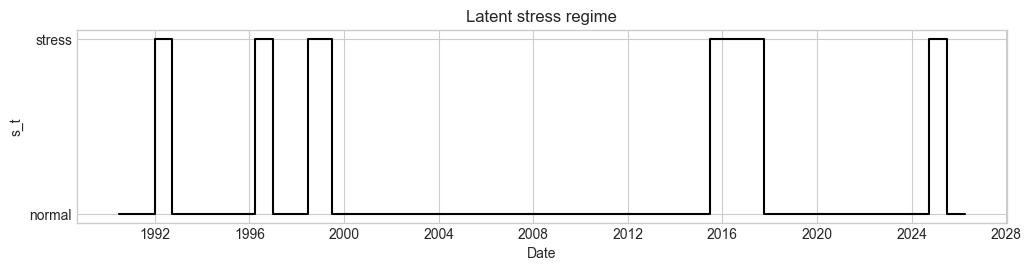

In [5]:
transition_matrix = np.array([
    [0.95, 0.05],  # normal -> normal, stress
    [0.20, 0.80],  # stress -> normal, stress
])

regime = np.zeros(len(df), dtype=int)
for t in range(1, len(df)):
    regime[t] = rng.choice([0, 1], p=transition_matrix[regime[t - 1]])

df["regime"] = regime
df["regime_label"] = np.where(df["regime"].eq(1), "stress", "normal")

display(df["regime_label"].value_counts(normalize=True).rename("share"))

fig, ax = plt.subplots(figsize=(12, 2.5))
ax.step(df["DATE"], df["regime"], where="post", color="black")
ax.set_title("Latent stress regime")
ax.set_ylabel("s_t")
ax.set_yticks([0, 1], ["normal", "stress"])
ax.set_xlabel("Date")
plt.show()

## 4. Generate simulated macro-financial variables

The variables below are intentionally simple:

- `sim_persistent_stress_indicator`: a persistent AR(1)-style signal that rises in stress.
- `sim_noisy_leading_indicator`: a noisy signal that partly anticipates next-quarter stress.
- `sim_irrelevant_noise`: unrelated noise, included as a decoy covariate.

In [6]:
n = len(df)
persistent = np.zeros(n)
for t in range(1, n):
    # Persistent stress indicator: slow-moving and higher when the latent regime is stress.
    persistent[t] = 0.80 * persistent[t - 1] + 0.70 * df.loc[t, "regime"] + rng.normal(0.0, 0.35)

# Noisy leading indicator: uses next period's regime where available, so it contains imperfect early warning information.
next_regime = df["regime"].shift(-1).fillna(df["regime"]).to_numpy()
leading = 0.90 * next_regime + rng.normal(0.0, 0.75, size=n)

# Irrelevant noise variable: deliberately unrelated to the regime and charge-offs.
irrelevant = rng.normal(0.0, 1.0, size=n)


def zscore(x):
    x = np.asarray(x, dtype=float)
    return (x - np.nanmean(x)) / np.nanstd(x)


df["sim_persistent_stress_indicator"] = zscore(persistent)
df["sim_noisy_leading_indicator"] = zscore(leading)
df["sim_irrelevant_noise"] = zscore(irrelevant)

sim_macro_cols = [
    "sim_persistent_stress_indicator",
    "sim_noisy_leading_indicator",
    "sim_irrelevant_noise",
]

display(df[["DATE", "regime", *sim_macro_cols]].head())
display(df[sim_macro_cols].describe().T)

,DATE,regime,sim_persistent_stress_indicator,sim_noisy_leading_indicator,sim_irrelevant_noise
0,1990-06-30,0,-0.541201,-1.253820,-1.369944
1,1990-09-30,0,-0.949527,-0.642118,0.432164
2,1990-12-31,0,-1.747634,0.061819,-1.023091
3,1991-03-31,0,-1.395878,-0.140436,0.515283
4,1991-06-30,0,-1.560397,-0.470400,-0.099749


,count,mean,std,min,25%,50%,75%,max
sim_persistent_stress_indicator,144.0,4.934325e-17,1.00349,-1.747634,-0.700908,-0.114221,0.642069,4.019528
sim_noisy_leading_indicator,144.0,1.233581e-17,1.00349,-2.648045,-0.588366,0.080443,0.636789,2.202929
sim_irrelevant_noise,144.0,7.709882e-18,1.00349,-2.976449,-0.673438,-0.029995,0.592197,2.670671


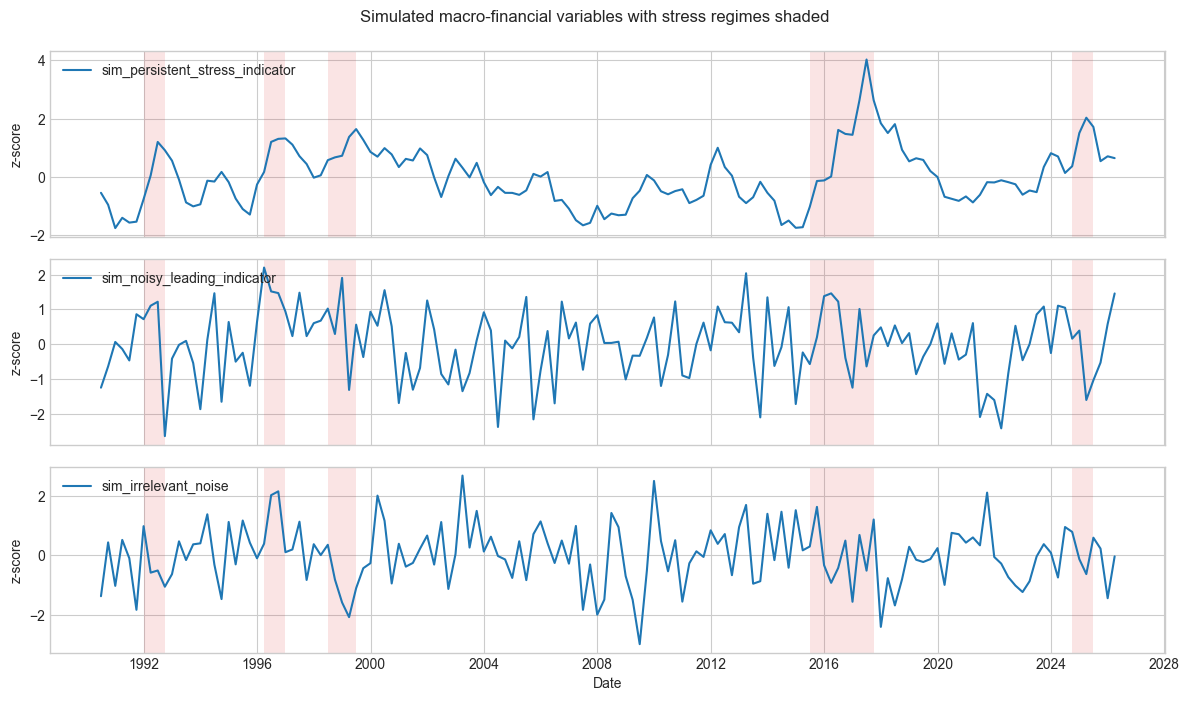

In [7]:
def shade_stress_periods(ax, dates, regimes, color="tab:red", alpha=0.12):
    dates = pd.Series(pd.to_datetime(dates)).reset_index(drop=True)
    regimes = pd.Series(regimes).reset_index(drop=True)
    in_stress = False
    start = None
    for i, is_stress in enumerate(regimes.eq(1)):
        if is_stress and not in_stress:
            start = dates.iloc[i]
            in_stress = True
        if in_stress and ((not is_stress) or i == len(regimes) - 1):
            end = dates.iloc[i] if not is_stress else dates.iloc[i]
            ax.axvspan(start, end, color=color, alpha=alpha, linewidth=0)
            in_stress = False


fig, axes = plt.subplots(len(sim_macro_cols), 1, figsize=(12, 7), sharex=True)
for ax, col in zip(axes, sim_macro_cols):
    ax.plot(df["DATE"], df[col], label=col)
    shade_stress_periods(ax, df["DATE"], df["regime"])
    ax.set_ylabel("z-score")
    ax.legend(loc="upper left")
axes[-1].set_xlabel("Date")
fig.suptitle("Simulated macro-financial variables with stress regimes shaded", y=0.995)
plt.tight_layout()
plt.show()

## 5. Generate simulated charge-off rates

Quarterly charge-off rates are generated from a transparent log-linear equation. The latent stress regime remains the main tail driver, the persistent stress indicator is the strongest observed predictor, and the lagged noisy leading indicator is weaker but still informative. The irrelevant noise variable is deliberately excluded from the true charge-off equation.

In [8]:
LGD = 0.45

# Lag the leading indicator by one quarter so charge-offs depend on information available at t-1.
df["sim_noisy_leading_indicator_lag1"] = df["sim_noisy_leading_indicator"].shift(1)
df["sim_noisy_leading_indicator_lag1"] = df["sim_noisy_leading_indicator_lag1"].fillna(
    df["sim_noisy_leading_indicator_lag1"].mean()
)

# Log-linear data-generating process:
# log(c_t) = base + regime_effect*s_t + beta_persistent*x_persistent_t
#            + beta_leading*x_leading_{t-1} + epsilon_t.
# The irrelevant noise variable is excluded by design.
base = np.log(0.0030)
regime_effect = 0.95
beta_persistent = 0.35
beta_leading = 0.15
epsilon_sd = 0.25

log_chargeoff = (
    base
    + regime_effect * df["regime"].to_numpy()
    + beta_persistent * df["sim_persistent_stress_indicator"].to_numpy()
    + beta_leading * df["sim_noisy_leading_indicator_lag1"].to_numpy()
    + rng.normal(0.0, epsilon_sd, size=n)
)

chargeoff = np.exp(log_chargeoff)
chargeoff = np.clip(chargeoff, 0.0005, 0.0400)

df["sim_charge_off_rate"] = chargeoff
df["sim_quarterly_pd"] = np.clip(df["sim_charge_off_rate"] / LGD, 1e-6, 0.25)
df["sim_annual_pd"] = np.clip(1.0 - (1.0 - df["sim_quarterly_pd"]) ** 4, 1e-6, 0.99)

display(df.groupby("regime_label")[["sim_charge_off_rate", "sim_quarterly_pd", "sim_annual_pd"]].describe())

sim_charge_off_rate                                          \
                           count      mean       std       min       25%   
regime_label                                                               
normal                     122.0  0.002914  0.001329  0.000926  0.002073   
stress                      22.0  0.014090  0.008293  0.004382  0.009078   

                                           sim_quarterly_pd            \
                   50%       75%       max            count      mean   
regime_label                                                            
normal        0.002687  0.003479  0.008106            122.0  0.006476   
stress        0.012871  0.016871  0.040000             22.0  0.031310   

                                                                          \
                   std       min       25%       50%       75%       max   
regime_label                                                               
normal        0.002954  0.002057  0.004608  0.005970  0.007731  0.018012   
stress        0.018430  0.009738  0.020173  0.028603  0.037491  0.088889   

             sim_annual_pd                                                   \
                     count      mean      std       min       25%       50%   
regime_label                                                                  
normal               122.0  0.025602  0.01152  0.008204  0.018303  0.023668   
stress                22.0  0.117693  0.06409  0.038388  0.078280  0.109595   

                                  
                   75%       max  
regime_label                      
normal        0.030568  0.070126  
stress        0.141722  0.310895

## 6. Plot generated charge-offs and PDs

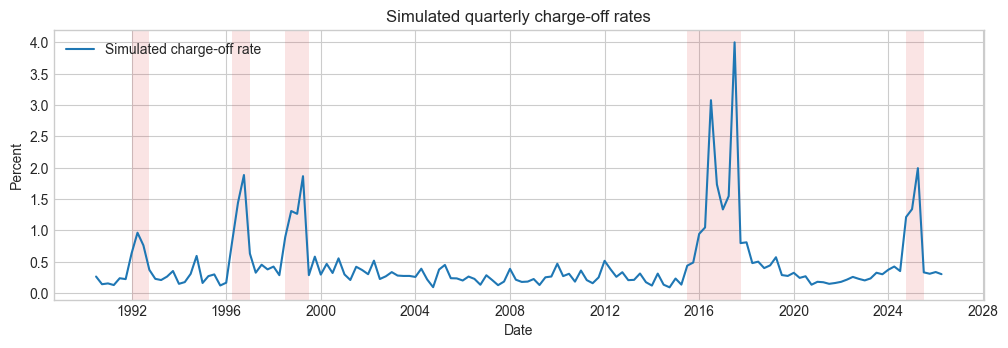

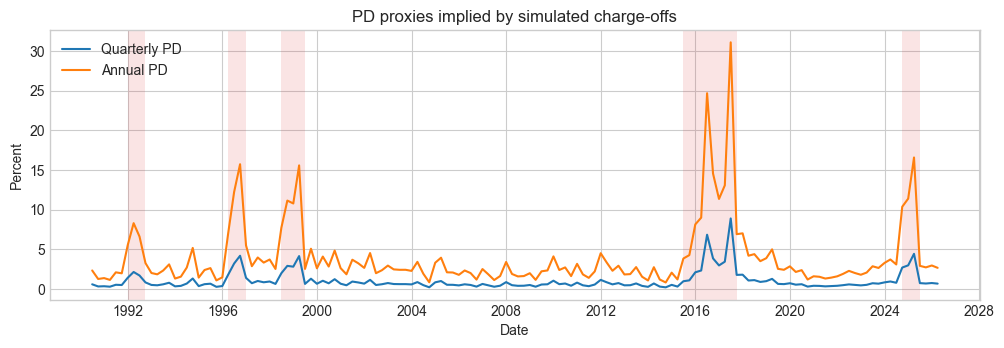

In [9]:
fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(df["DATE"], 100 * df["sim_charge_off_rate"], color="tab:blue", label="Simulated charge-off rate")
shade_stress_periods(ax, df["DATE"], df["regime"])
ax.set_title("Simulated quarterly charge-off rates")
ax.set_ylabel("Percent")
ax.set_xlabel("Date")
ax.legend(loc="upper left")
plt.show()

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(df["DATE"], 100 * df["sim_quarterly_pd"], label="Quarterly PD")
ax.plot(df["DATE"], 100 * df["sim_annual_pd"], label="Annual PD")
shade_stress_periods(ax, df["DATE"], df["regime"])
ax.set_title("PD proxies implied by simulated charge-offs")
ax.set_ylabel("Percent")
ax.set_xlabel("Date")
ax.legend(loc="upper left")
plt.show()

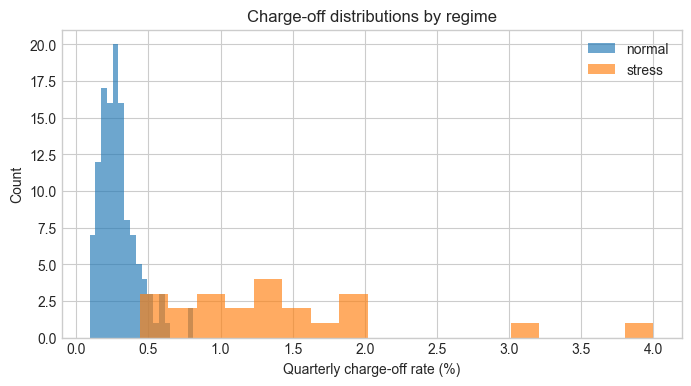

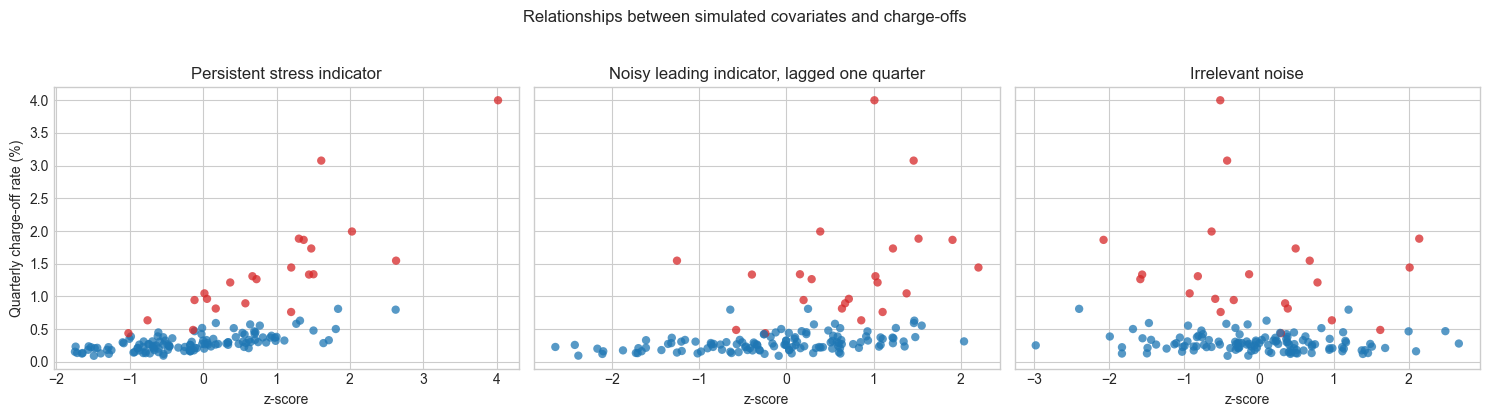

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
for label, group in df.groupby("regime_label"):
    ax.hist(100 * group["sim_charge_off_rate"], bins=18, alpha=0.65, label=label)
ax.set_title("Charge-off distributions by regime")
ax.set_xlabel("Quarterly charge-off rate (%)")
ax.set_ylabel("Count")
ax.legend()
plt.show()

scatter_specs = [
    ("sim_persistent_stress_indicator", "Persistent stress indicator"),
    ("sim_noisy_leading_indicator_lag1", "Noisy leading indicator, lagged one quarter"),
    ("sim_irrelevant_noise", "Irrelevant noise"),
]

fig, axes = plt.subplots(1, len(scatter_specs), figsize=(15, 4), sharey=True)
colors = np.where(df["regime"].eq(1), "tab:red", "tab:blue")
for ax, (col, title) in zip(axes, scatter_specs):
    ax.scatter(df[col], 100 * df["sim_charge_off_rate"], c=colors, alpha=0.75, edgecolor="none")
    ax.set_title(title)
    ax.set_xlabel("z-score")
axes[0].set_ylabel("Quarterly charge-off rate (%)")
fig.suptitle("Relationships between simulated covariates and charge-offs", y=1.03)
plt.tight_layout()
plt.show()

## 7. Optional oracle allocation preview

This preview uses the existing optimisation utility if it is available. It is only an oracle diagnostic from realised simulated charge-offs; no PtO, black-box, or DFL model is trained here.

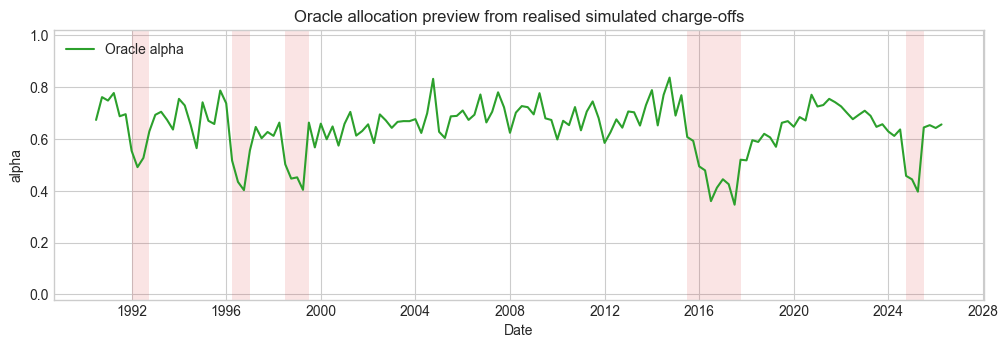

,DATE,regime_label,sim_charge_off_rate,sim_oracle_alpha
0,1990-06-30,normal,0.002646,0.673303
1,1990-09-30,normal,0.001424,0.761294
2,1990-12-31,normal,0.001550,0.748044
3,1991-03-31,normal,0.001291,0.777172
4,1991-06-30,normal,0.002376,0.687454


In [11]:
if HAS_OPTIMISATION_UTILS:
    cap_cfg = CapitalConfig(lgd=LGD, leverage=10)
    df["sim_oracle_alpha"] = [optimise_oracle_alpha(float(c), cap_cfg) for c in df["sim_charge_off_rate"]]

    fig, ax = plt.subplots(figsize=(12, 3.5))
    ax.plot(df["DATE"], df["sim_oracle_alpha"], color="tab:green", label="Oracle alpha")
    shade_stress_periods(ax, df["DATE"], df["regime"])
    ax.set_title("Oracle allocation preview from realised simulated charge-offs")
    ax.set_ylabel("alpha")
    ax.set_xlabel("Date")
    ax.set_ylim(-0.02, 1.02)
    ax.legend(loc="upper left")
    plt.show()

    display(df[["DATE", "regime_label", "sim_charge_off_rate", "sim_oracle_alpha"]].head())
else:
    print("Placeholder: add oracle alpha here once optimisation utilities are available.")

## 8. Save output

In [12]:
output_dir = REPO_ROOT / "models" / "simulation" / "data"
output_dir.mkdir(parents=True, exist_ok=True)

simulation_output_cols = [
    "DATE",
    "regime",
    "regime_label",
    "sim_persistent_stress_indicator",
    "sim_noisy_leading_indicator",
    "sim_noisy_leading_indicator_lag1",
    "sim_irrelevant_noise",
    "sim_charge_off_rate",
    "sim_quarterly_pd",
    "sim_annual_pd",
]
if "sim_oracle_alpha" in df.columns:
    simulation_output_cols.append("sim_oracle_alpha")

sim_output_df = df[simulation_output_cols].copy()

output_csv = output_dir / "simulated_variables.csv"
sim_output_df.to_csv(output_csv, index=False)

print(f"Saved simulated modelling dataframe to: {output_csv.relative_to(REPO_ROOT)}")
display(sim_output_df.head())

Saved simulated modelling dataframe to: models/simulation/data/simulated_variables.csv


,DATE,regime,regime_label,sim_persistent_stress_indicator,sim_noisy_leading_indicator,sim_noisy_leading_indicator_lag1,sim_irrelevant_noise,sim_charge_off_rate,sim_quarterly_pd,sim_annual_pd,sim_oracle_alpha
0,1990-06-30,0,normal,-0.541201,-1.253820,-0.010188,-1.369944,0.002646,0.005881,0.023316,0.673303
1,1990-09-30,0,normal,-0.949527,-0.642118,-1.253820,0.432164,0.001424,0.003164,0.012595,0.761294
2,1990-12-31,0,normal,-1.747634,0.061819,-0.642118,-1.023091,0.001550,0.003444,0.013704,0.748044
3,1991-03-31,0,normal,-1.395878,-0.140436,0.061819,0.515283,0.001291,0.002869,0.011429,0.777172
4,1991-06-30,0,normal,-1.560397,-0.470400,-0.140436,-0.099749,0.002376,0.005280,0.020954,0.687454
